   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.0 MB/s eta 0:00:00
🔹 Loading DICOMs from: /content/drive/MyDrive/Major project Final models/major project dataset
✅ Loaded 581 DICOM slices.
Sample SUV values: [np.float32(1628.1245), np.float32(1836.9364), np.float32(2123.7168), np.float32(2159.2512), np.float32(2029.6078), np.float32(2396.5334), np.float32(1904.651), np.float32(2123.3445), np.float32(2067.3608), np.float32(2183.9744)]
🚦 Using threshold (percentile 50) = 2067.75
📊 Class distribution: 291 (Fibrosis), 290 (Tumor)
💾 Saved SUV values and labels → /content/drive/MyDrive/Major project Final models/major project dataset/suv_values_labels.csv


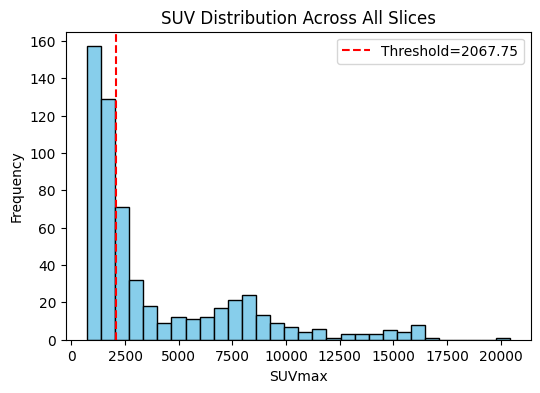

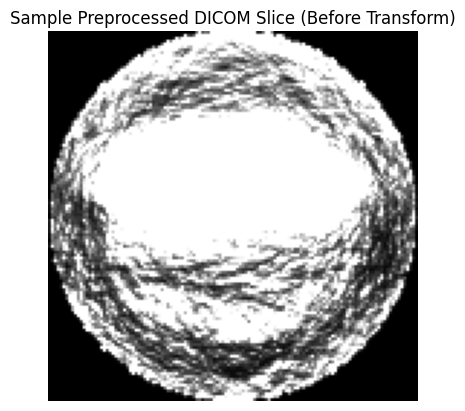


📁 Dataset split → Train: 464, Validation: 117
🖥️ Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Training Epoch 1/5:   0%|          | 0/116 [00:00<?, ?it/s]

Epoch 1: Loss=0.4100, Train Acc=82.33%
✅ Validation Accuracy: 85.47%


Training Epoch 2/5:   0%|          | 0/116 [00:00<?, ?it/s]

...

Epoch 3: Loss=0.2875, Train Acc=88.36%
✅ Validation Accuracy: 88.03%


Training Epoch 4/5:   0%|          | 0/116 [00:00<?, ?it/s]

Epoch 4: Loss=0.2451, Train Acc=90.30%
✅ Validation Accuracy: 89.74%


Training Epoch 5/5:   0%|          | 0/116 [00:00<?, ?it/s]

Epoch 5: Loss=0.2637, Train Acc=88.15%
✅ Validation Accuracy: 88.89%


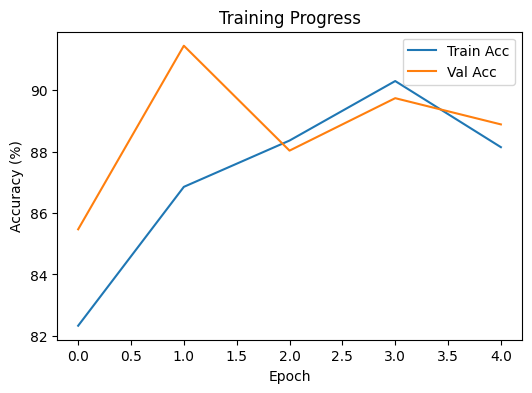

In [2]:
# -------------------------------
# Import libraries
# -------------------------------

!pip install pydicom
import os
import pydicom
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from tqdm.notebook import tqdm
import csv
import matplotlib.pyplot as plt

# -------------------------------
# 1. SUV Calculation
# -------------------------------
def calculate_suv(dcm, body_weight_kg=70.0):
    """Compute SUV from PET DICOM."""
    try:
        pixel_array = dcm.pixel_array.astype(np.float32)
        slope = float(getattr(dcm, "RescaleSlope", 1.0))
        intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
        activity = pixel_array * slope + intercept

        if hasattr(dcm, "RadiopharmaceuticalInformationSequence"):
            rph = dcm.RadiopharmaceuticalInformationSequence[0]
            injected_dose = float(getattr(rph, "RadionuclideTotalDose", 370e6))
        else:
            injected_dose = 370e6

        injected_dose_kBq = injected_dose / 1000.0
        body_weight_g = body_weight_kg * 1000.0

        suv = activity / (injected_dose_kBq / body_weight_g)
        return np.max(suv)
    except Exception as e:
        print("SUV calc failed:", e)
        return 0.0

# -------------------------------
# 2. Custom Dataset with detailed logs
# -------------------------------
class BreastDataset(Dataset):
    def __init__(self, main_folder, transform=None, save_csv=True, percentile=50, show_samples=True):
        self.image_paths, self.suv_values, self.labels = [], [], []
        self.transform = transform

        print("🔹 Loading DICOMs from:", main_folder)
        for patient_folder in sorted(os.listdir(main_folder)):
            patient_path = os.path.join(main_folder, patient_folder)
            if os.path.isdir(patient_path):
                for dicom_file in os.listdir(patient_path):
                    if dicom_file.endswith(".dcm"):
                        full_path = os.path.join(patient_path, dicom_file)
                        self.image_paths.append(full_path)
                        dcm = pydicom.dcmread(full_path)
                        suv_max = calculate_suv(dcm)
                        self.suv_values.append(suv_max)

        print(f"✅ Loaded {len(self.image_paths)} DICOM slices.")
        print("Sample SUV values:", self.suv_values[:10])

        # Automatic threshold
        self.threshold = np.percentile(self.suv_values, percentile)
        print(f"🚦 Using threshold (percentile {percentile}) = {self.threshold:.2f}")

        # Label generation
        self.labels = [1 if suv > self.threshold else 0 for suv in self.suv_values]
        print(f"📊 Class distribution: {self.labels.count(0)} (Fibrosis), {self.labels.count(1)} (Tumor)")

        # Save CSV
        if save_csv:
            csv_path = os.path.join(main_folder, "suv_values_labels.csv")
            with open(csv_path, mode="w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(["slice_path", "SUVmax", "label"])
                for path, suv, label in zip(self.image_paths, self.suv_values, self.labels):
                    writer.writerow([path, suv, label])
            print(f"💾 Saved SUV values and labels → {csv_path}")

        # Show histogram of SUV values
        plt.figure(figsize=(6,4))
        plt.hist(self.suv_values, bins=30, color='skyblue', edgecolor='black')
        plt.axvline(self.threshold, color='r', linestyle='--', label=f"Threshold={self.threshold:.2f}")
        plt.title("SUV Distribution Across All Slices")
        plt.xlabel("SUVmax")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

        # Show sample preprocessed image
        if show_samples:
            dcm = pydicom.dcmread(self.image_paths[0])
            img_array = dcm.pixel_array.astype(np.float32)
            img_array = np.clip(img_array, 0, 20)
            norm = (img_array - np.min(img_array)) / (np.max(img_array)-np.min(img_array)+1e-5)
            plt.imshow(norm, cmap='gray')
            plt.title("Sample Preprocessed DICOM Slice (Before Transform)")
            plt.axis('off')
            plt.show()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        dcm = pydicom.dcmread(self.image_paths[idx])
        img_array = dcm.pixel_array.astype(np.float32)
        img_array = np.clip(img_array, 0, 20)
        img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array) + 1e-5)
        img_array = (img_array * 255).astype(np.uint8)
        img = Image.fromarray(img_array).convert("RGB")

        if self.transform:
            img = self.transform(img)

        suv = np.log1p(self.suv_values[idx])
        label = self.labels[idx]
        return img, torch.tensor(label, dtype=torch.long), torch.tensor(suv, dtype=torch.float32)

# -------------------------------
# 3. Model
# -------------------------------
class ResNet9(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet18(weights=None)
        self.resnet.fc = nn.Identity()
    def forward(self, x): return self.resnet(x)

class SimpleViT(nn.Module):
    def __init__(self, img_dim=224, patch_dim=16, dim=256, depth=3, heads=4, mlp_dim=512):
        super().__init__()
        from torch.nn import TransformerEncoder, TransformerEncoderLayer
        num_patches = (img_dim // patch_dim) ** 2
        patch_dim_flat = 3 * patch_dim * patch_dim
        self.patch_dim = patch_dim
        self.dim = dim
        self.patch_to_embedding = nn.Linear(patch_dim_flat, dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        encoder_layer = TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim)
        self.transformer = TransformerEncoder(encoder_layer, num_layers=depth)
    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_dim
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, C, -1, p, p)
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(B, -1, C * p * p)
        x = self.patch_to_embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :x.size(1)]
        x = self.transformer(x)
        return x[:, 0]

class HybridModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.resnet = ResNet9()
        self.vit = SimpleViT()
        self.suv_fc = nn.Sequential(nn.Linear(1,32), nn.ReLU(), nn.Linear(32,64))
        self.fc = nn.Sequential(nn.Linear(512+256+64,256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256,num_classes))
    def forward(self,img,suv):
        res_feat = self.resnet(img)
        vit_feat = self.vit(img)
        suv_feat = self.suv_fc(suv.unsqueeze(1))
        combined = torch.cat([res_feat, vit_feat, suv_feat], dim=1)
        return self.fc(combined)

# -------------------------------
# 4. Training with live logs
# -------------------------------
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-4, device="cuda"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct, total = 0, 0
        for imgs, labels, suvs in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{epochs}"):
            imgs, labels, suvs = imgs.to(device), labels.to(device), suvs.to(device)
            optimizer.zero_grad()
            outputs = model(imgs, suvs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_accs.append(train_acc)
        print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}, Train Acc={train_acc:.2f}%")

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels, suvs in val_loader:
                imgs, labels, suvs = imgs.to(device), labels.to(device), suvs.to(device)
                outputs = model(imgs, suvs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        val_accs.append(val_acc)
        print(f"✅ Validation Accuracy: {val_acc:.2f}%")

    # Plot accuracy curves
    plt.figure(figsize=(6,4))
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.title("Training Progress")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.show()

# -------------------------------
# 5. Run end-to-end
# -------------------------------
main_folder = "/content/drive/MyDrive/Major project Final models/major project dataset"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

dataset = BreastDataset(main_folder, transform=transform, save_csv=True, percentile=50, show_samples=True)

train_size = int(0.8*len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"\n📁 Dataset split → Train: {train_size}, Validation: {val_size}")

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("🖥️ Using device:", device)

model = HybridModel(num_classes=2)
train_model(model, train_loader, val_loader, epochs=5, device=device)
